In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [52]:
df = pd.read_csv("voice.csv")

print("Quantidade de linhas e colunas:")
print(df.shape)

df.head()

Quantidade de linhas e colunas:
(3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [53]:
df.info()

print("\nEstatísticas do Dataset:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

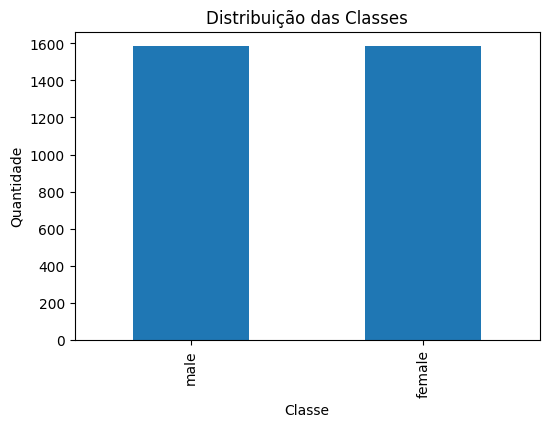

In [54]:
plt.figure(figsize=(6,4))

df["label"].value_counts().plot(kind="bar")

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

In [55]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["label"])

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,1
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,1
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,1
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,1
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,1


In [56]:
X = df.drop("label", axis=1)

y = df["label"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [58]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [59]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [60]:
pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print("Acurácia KNN:", acc_knn)

Acurácia KNN: 0.9737118822292324


In [61]:
print(classification_report(y_test, pred_knn))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       452
           1       0.97      0.98      0.98       499

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



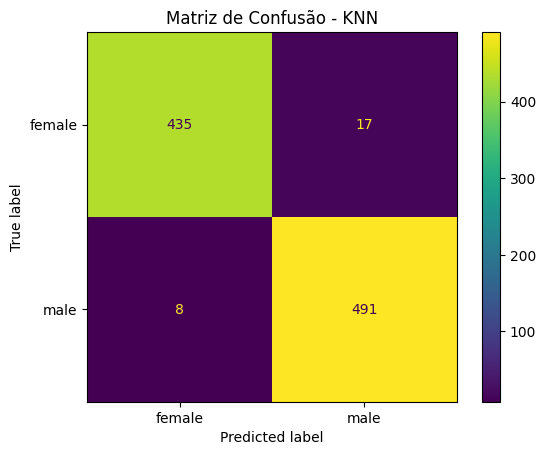

In [62]:
cm_knn = confusion_matrix(y_test, pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("Matriz de Confusão - KNN")

plt.show()

In [63]:
svm = SVC(kernel="linear")

svm.fit(X_train, y_train)

SVC(kernel='linear')

In [64]:
pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, pred_svm)

print("Acurácia SVM:", acc_svm)

Acurácia SVM: 0.9705573080967402


In [65]:
print(classification_report(y_test, pred_svm))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       452
           1       0.97      0.97      0.97       499

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



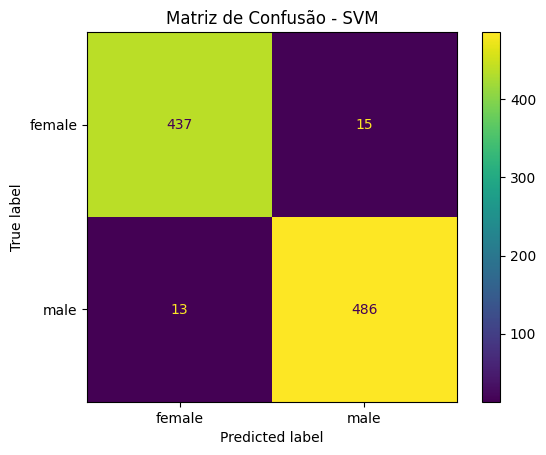

In [66]:
cm_svm = confusion_matrix(y_test, pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("Matriz de Confusão - SVM")

plt.show()

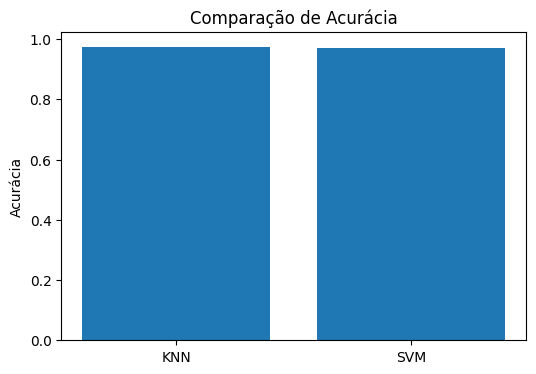

In [67]:
modelos = ["KNN", "SVM"]

acuracias = [
    acc_knn,
    acc_svm
]

plt.figure(figsize=(6,4))

plt.bar(modelos, acuracias)

plt.title("Comparação de Acurácia")
plt.ylabel("Acurácia")

plt.show()

In [68]:
comparacao = pd.DataFrame({
    "Modelo": ["KNN", "SVM"],
    "Acurácia": [acc_knn, acc_svm]
})

comparacao

,Modelo,Acurácia
0,KNN,0.973712
1,SVM,0.970557


In [69]:
amostra = X_test[0:1]

resultado = svm.predict(amostra)

print(
    "Classe prevista:",
    encoder.inverse_transform(resultado)
)

Classe prevista: ['female']


In [70]:
print("Acurácia KNN:", acc_knn)
print("Acurácia SVM:", acc_svm)

Acurácia KNN: 0.9737118822292324
Acurácia SVM: 0.9705573080967402
